# Get PhyloMInt results
This notebook presents PhyloMInt seed searching.

To run correctly this notebook and have the same results as the paper, you must first download the raw results: [https://doi.org/10.57745/OS1JND](https://doi.org/10.57745/OS1JND)

This notebook is written with the hierarchy of downloaded files, if you want to try it with the test form the run notebooks, it is needed to first restructure your data to match the hierarchy of downloaded files.

We suppose here that the downloaded files are in a directory named "analyses", this directory path can be changed to your directory path where the data are saved.

## Requirements
Module *pandas*, *numpy*, *seaborn* and *scipy* are needed

In [ ]:
!pip install pandas

In [ ]:
!pip install numpy

In [ ]:
!pip install seaborn

In [ ]:
!pip install scipy

# Variable to change (if wanted)

In [1]:
analyse_dir = "../../analyses"

# Initialisation and functions

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import numpy as np
from json import load

In [4]:
phylomint_dir = os.path.join(analyse_dir, "results", "phylomint")
phylomint_scope_dir = os.path.join(phylomint_dir, "scopes")
phylomint_fluxes_dir=os.path.join(phylomint_dir,"fluxes")

phylomint_duplicate_rev_dir = os.path.join(analyse_dir, "results", "phylomint_duplicate_rev", "seeds_results")
netseed_results_dir = os.path.join(analyse_dir,  "results", "netseed")

s2lp_results_reas_dir = os.path.join(analyse_dir,  "results", "s2lp_reasoning")
s2lp_scope_dir = os.path.join(analyse_dir,  "results", "scopes_s2lp")
s2lp_supp_data = os.path.join(analyse_dir, "results", "supp_data", "seed2lp_supp_data.tsv")

## For NetSeed and PhyloMInt comparison
Phylomint results with reversible reaction duplicated

In [5]:
def load_json(file):   
    file = open(file)
    result = load(file)
    file.close()
    return result

In [6]:
def get_seeds_netseed(netseed_dir):
    netseed_all = pd.DataFrame(columns=['species','seeds'])
    for species in os.listdir(netseed_dir):
        result_path = os.path.join(netseed_dir, species,"netseed","results.json")
        data = load_json(result_path)
        solutions = data["netseed"]["solutions"]["union"]
        current_df =  pd.DataFrame([[species, solutions]], columns=['species','seeds'])
        netseed_all=pd.concat([netseed_all, current_df], ignore_index=True)
    netseed_all=netseed_all.set_index("species")
    return netseed_all

def get_seeds_pylomint(phylomint_dir):
    phylomint_all = pd.DataFrame(columns=['species','seeds'])
    for file in os.listdir(phylomint_dir):
        species = f'{os.path.splitext(os.path.basename(file))[0]}'
        species = species.replace('_duplicate_results', '')
        result_path = os.path.join(phylomint_dir, file)
        data = load_json(result_path)
        solutions = data["RESULTS"]["Phylomint"]["MINIMIZE ENUMERATION"]["solutions"]["model_1"][3]
        current_df =  pd.DataFrame([[species, solutions]], columns=['species','seeds'])
        phylomint_all=pd.concat([phylomint_all, current_df], ignore_index=True)
    phylomint_all=phylomint_all.set_index("species")
    return phylomint_all

In [7]:
def compare_seeds(netseed_all:pd.DataFrame, phylomint_all:pd.DataFrame):
    dict_compare=dict()
    for species, seeds in netseed_all.iterrows():
        netseed_set = set(list(seeds)[0])
        phylomint_set = set(list(phylomint_all.loc[species])[0])
        dict_compare[species] = netseed_set==phylomint_set

    return dict_compare

## For PhyloMint and Seed2LP comparison
Phylomint results from original seed search

In [8]:
def get_scopes(directory:str):
    scope_all=pd.DataFrame(columns=['species','model',
                                'is_biomass_included', 'missing_biomass', 'percentage_missing_biomass'])
    for species in os.listdir(directory):
        file_path = os.path.join(directory, species, "scope", "phylomint", "phylomint", "minimize", "accu", f"{species}_compare.tsv")
        current_df = pd.read_csv(file_path, sep='\t', lineterminator='\n')
        current_df['is_biomass_included'] = current_df['is_biomass_included'].map({True: 'True', False: 'False'})
        current_df["percentage_similar_biomass"]=100-current_df["percentage_missing_biomass"]
        scope_all=pd.concat([scope_all, current_df], ignore_index=True)

    return scope_all


In [9]:
def get_scopes(directory:str, mode:str, optim:str=None):
    scope_all=pd.DataFrame(columns=['species','run','mode','optim', 'accu','model',
                                'is_equal_union_species', 'missing', 'percentage_missing',
                                'is_biomass_included', 'missing_biomass', 'percentage_missing_biomass',
                                'is_exchange_included', 'missing_exchange', 'percentage_missing_exchange',
                                'is_seed_included_to_exchange', 'missing_seed_into_exchange', 'percentage_missing_seed_into_exchange',
                                'is_exchange_included_to_seed', 'missing_exchange_into_seed', 'percentage_missing_exchange_into_seeds'])
    if mode == "phylomint":
        prefix="phylomint"
    else:
        prefix="scope"
    for species in os.listdir(directory):
        if mode == "phylomint":
            file_path = os.path.join(directory, species, "scope", "phylomint", "phylomint", "minimize", "accu", f"{species}_{prefix}_compare.tsv")
        else:
            file_path = os.path.join(directory, species, f"{species}_{prefix}_compare.tsv")
        current_df = pd.read_csv(file_path, sep='\t', lineterminator='\n')
        current_df['is_equal_union_species'] = current_df['is_equal_union_species'].map({True: 'True', False: 'False'})
        current_df['is_biomass_included'] = current_df['is_biomass_included'].map({True: 'True', False: 'False'})
        current_df['is_exchange_included'] = current_df['is_exchange_included'].map({True: 'True', False: 'False'})
        current_df['is_seed_included_to_exchange'] = current_df['is_seed_included_to_exchange'].map({True: 'True', False: 'False'})
        current_df['is_exchange_included_to_seed'] = current_df['is_exchange_included_to_seed'].map({True: 'True', False: 'False'})
        current_df["percentage_similar"]=100-current_df["percentage_missing"]
        current_df["percentage_similar_biomass"]=100-current_df["percentage_missing_biomass"]
        current_df["percentage_similar_exchange"]=100-current_df["percentage_missing_exchange"]
        current_df["percentage_similar_seed_into_exchange"]=100-current_df["percentage_missing_seed_into_exchange"]
        current_df["percentage_similar_exchange_into_seeds"]=100-current_df["percentage_missing_exchange_into_seeds"]
        scope_all=pd.concat([scope_all, current_df], ignore_index=True)
    # in this notebook we use only reasoning and only the non accumulation mode for Seed2LP
    if mode == "full":
        scope_all = scope_all[scope_all["mode"]=="reasoning"]
        scope_all = scope_all[scope_all["accu"]==False]
        scope = scope_all[scope_all["run"]=="full"]
    elif mode == "target":
        scope_all = scope_all[scope_all["mode"]=="reasoning"]
        scope_all = scope_all[scope_all["accu"]==False]
        scope = scope_all[scope_all["run"]=="target"]
    else:
        scope = scope_all

    if optim=="submin":
        return scope[scope["optim"]=="subset_minimal"]
    elif optim=="min":
        return scope[scope["optim"]=="minimize"]
    else:
        return scope

In [10]:
def get_fluxes(directory:str, mode:str, optim:str=None):
    flux_all=pd.DataFrame(columns=['species', 'biomass_reaction', 'solver_type', 'search_mode',
                                     'search_type', 'accumulation', 'model', 'size', 'lp_flux', 'cobra_flux_init',
                                     'cobra_flux_no_import', 'cobra_flux_seeds', 'cobra_flux_demands',
                                     'has_flux', 'has_flux_seeds', 'has_flux_demands', 'timer'])
    flux_all['accumulation'] = flux_all['accumulation'].astype('bool')
    flux_all['has_flux'] = flux_all['has_flux'].astype('bool')
    flux_all['has_flux_seeds'] = flux_all['has_flux_seeds'].astype('bool')
    flux_all['has_flux_demands'] = flux_all['has_flux_demands'].astype('bool')

    for dirpath, _, filenames in os.walk(directory):
        for filename in [f for f in filenames if (f.endswith("_fluxes.tsv") or f.endswith("_fluxes_from_result.tsv"))]:
            # By default in this notebook we want the no accumulation mode for seed2lp results
            if  "_no_accu_" in filename \
                and   ((mode == "full" and "_fn_" in filename) \
                    or (mode == "target" and "_tgt_" in filename))\
                or mode == "phylomint":
                file_path=os.path.join(dirpath, filename)
                current_df = pd.read_csv(file_path, sep='\t', lineterminator='\n')
                current_df['accumulation'] = current_df['accumulation'].astype('bool')
                current_df['has_flux'] = current_df['has_flux'].astype('bool')
                current_df['has_flux_seeds'] = current_df['has_flux_seeds'].astype('bool')
                current_df['has_flux_demands'] = current_df['has_flux_demands'].astype('bool')
                flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)
    if optim=="submin":
        return flux_all[flux_all["search_mode"]=="Subset Minimal"]
    elif optim=="min":
        return flux_all[flux_all["search_mode"]=="Minimize"]
    else:
        return flux_all

In [11]:
def get_sizes(flux_df:pd.DataFrame, nb_total_meta:pd.DataFrame):
    list_mean_size = flux_df.groupby(['species'])['size'].mean()
    mean_size_df = pd.DataFrame(list_mean_size)
    data_size_df = pd.concat([nb_total_meta, mean_size_df], axis=1)
    data_size_df["percent"]=data_size_df["size"] / data_size_df["number_metabolites"] *100
    data_size = pd.DataFrame(data_size_df["percent"])
    data_size=data_size.reset_index()
    data_size=data_size.rename(columns={"index": "species"})
    return data_size

In [12]:
def plot_compare(df1:pd.DataFrame, df2:pd.DataFrame, col, labels, y_label:str=""):
    np.set_printoptions(precision=3)
    plt.style.use("seaborn-v0_8-colorblind")


    nan_spec=df1[df1[col].isnull()]["species"]
    for nspe in nan_spec:
        df1=df1.drop(df1.loc[df1['species']==nspe].index)

    nan_spec=df2[df2[col].isnull()]["species"]
    for nspe in nan_spec:
        df2=df2.drop(df2.loc[df2['species']==nspe].index)

    del_spec=set(df2['species']) - set(df1['species'])
    for sp in del_spec:
        df2=df2.drop(df2.loc[df2['species']==sp].index)

    n = len(df1['species'].unique())
    
    df1=df1.assign(Tool=labels[0])
    df2=df2.assign(Tool=labels[1])
    
    concat_table = pd.concat([df1, df2])

    scope_tab = concat_table.groupby(['species','Tool'])[col].mean()
    scope_df=pd.DataFrame(scope_tab)
    scope_df=scope_df.reset_index()
    plt.figure(figsize=(3,4))
    sns.set_theme(font_scale = 1.5)


    df1_means= scope_df[scope_df['Tool']==labels[0]]
    df2_means= scope_df[scope_df['Tool']==labels[1]]
    df1_gen_mean=df1_means[col].mean()
    df2_means=df2_means[col].mean()
    print(labels[0], " global mean: ",df1_gen_mean, "\t ", labels[1], "global mean: ", df2_means)


    # KRUSKAL WALLIS TESTS
    # Get the p-value from Kruskall Wallis test
    kstat, p_value = kruskal(scope_df[scope_df["Tool"]==labels[1]][col], scope_df[scope_df["Tool"]==labels[0]][col])

    sns.boxplot(data=scope_df, x="Tool", y=col, hue="Tool", fill=False, linewidth=1.5)
    plt.xlabel('')
    plt.ylabel(y_label)
    plt.title(f"kstat = {kstat}, p-value = {p_value}, n={n}")
    sns.despine(bottom=True)


    
    pict_dir="/home/cghassem/Projets/seed-2-lp/picture/"
    match col:
        case "percentage_similar_exchange_into_seeds":
            supp="exchange"
        case "percent":
            supp="size"
        case "percentage_similar_biomass":
            supp="biomass"
        case "percentage_similar":
            supp="full"
    plt.savefig(pict_dir+f'phylomint_{supp}.pdf', bbox_inches='tight')

In [13]:
def create_table_plot(table,column_name):
    new_table = table.groupby(['species'])[column_name].agg('count').reset_index()
    new_table=new_table.rename(columns={column_name: "Total_flux"})
    new_true = table[table[column_name]==True].groupby(['species'])[column_name].agg('count').reset_index()
    new_true=new_true.rename(columns={column_name: "True_flux"})
    new_false = table[table[column_name]==False].groupby(['species'])[column_name].agg('count').reset_index()
    new_false=new_false.rename(columns={column_name: "False_flux"})
    new_table=pd.merge(new_table,new_true, how='left', on=['species'])
    new_table=pd.merge(new_table,new_false, how='left', on=['species'])
    new_table=new_table.fillna(0)
    new_table=new_table.fillna(0)
    new_table['True_flux']=new_table['True_flux'].astype(int)
    new_table['False_flux']=new_table['False_flux'].astype(int)
    return new_table

In [14]:
def get_all_same_validation_fba(table,type):
    count=0
    total=0
    for _,line in table.iterrows():
        if line[type] == line["Total_flux"]:
            count += 1
            total += 1
        else:
            total += 1
    
    return total, count

In [15]:
def create_one_plot(s2lp, phylomint, labels, s2lp_scope, phylomint_scope):
    plt.style.use("seaborn-v0_8-colorblind")

    _, s2lp_true_count = get_all_same_validation_fba(s2lp, "True_flux")
    _, s2lp_false_count = get_all_same_validation_fba(s2lp,"False_flux")
    s2lp_missing_networks = 107 - (s2lp_true_count + s2lp_false_count)

    phylomint_true_count = phylomint.has_flux.sum()
    phylomint_false_count = (~phylomint.has_flux).sum()
    phylomint_missing_networks = 107 - (phylomint_true_count + phylomint_false_count)


   #Get Biomass into scope info
    s2lp_scope_mean_by_species = s2lp_scope.groupby(['species'])['percentage_similar_biomass'].mean()
    phylomint_scope_mean_by_species = phylomint_scope.groupby(['species'])['percentage_similar_biomass'].mean()

    s2lp_true_scope_count = s2lp_scope_mean_by_species.value_counts()[100]
    s2lp_true_no_scope_count = s2lp_true_count - s2lp_true_scope_count

    phylomint_true_scope_count = phylomint_scope_mean_by_species.value_counts()[100]
    phylomint_true_no_scope_count = phylomint_true_count - phylomint_true_scope_count


    # create seaprate value plot
    s2lp_tab=pd.DataFrame([[s2lp_true_scope_count, s2lp_true_no_scope_count, s2lp_false_count, s2lp_missing_networks]], 
                          columns=["all_true_scope","all_true_no_scope","all_false","missing"])
    s2lp_tab=s2lp_tab.assign(Tool=labels[0])

    phylomint_tab=pd.DataFrame([[phylomint_true_scope_count, phylomint_true_no_scope_count, phylomint_false_count, phylomint_missing_networks]],
                              columns=["all_true_scope","all_true_no_scope","all_false","missing"])
    phylomint_tab=phylomint_tab.assign(Tool=labels[1])
    concat_table = pd.concat([phylomint_tab,s2lp_tab])


    plt.figure(figsize=(1,3))
    sns.set_theme(font_scale = 1.5)
    fig, ax = plt.subplots()
    fig.tight_layout()
    groups = concat_table['Tool']
    ax.bar(groups, concat_table["all_true_scope"], color='#1e73be',label='flux & scope', width=0.2)
    ax.bar(groups, concat_table["all_true_no_scope"], bottom = concat_table["all_true_scope"], 
           color='#945cb4', label='flux', width=0.2)
    ax.bar(groups, concat_table["all_false"], bottom = concat_table["all_true_scope"]+concat_table["all_true_no_scope"], 
           color='#ef3340', label='no flux', width=0.2)
    ax.bar(groups, concat_table["missing"], bottom =  concat_table["all_true_scope"]+concat_table["all_true_no_scope"]+concat_table["all_false"], 
           color='black', label='no solution', width=0.2)
    
    plt.ylabel('Number of GSMNs', fontsize=25)
    plt.xlabel('Tools', fontsize=25)
    plt.xticks(size=22)
    plt.yticks(size=22)
    #sns.despine(bottom=True)
    plt.tick_params(bottom=False, left=True)
    plt.legend(frameon=True,  loc='center right', borderaxespad=-10)

    pict_dir="/home/cghassem/Projets/seed-2-lp/picture/"
    plt.savefig(pict_dir+'phylomint_flux.pdf', bbox_inches='tight')
    return 

In [16]:
def get_result_compare(dictionnary):
    nb_true = sum(dictionnary.values())
    print(f"There is {nb_true}/107 networks with identical set of seeds between NetSeed and PhyloMInt with only reversible reaction duplicated")

In [17]:
def get_total_nb_meta(supp_data_file):
    table_all = pd.read_csv(supp_data_file, sep='\t', lineterminator='\n')
    union_all = table_all.loc[table_all["type_data"] == "Union"]
    num_metabolite = union_all.groupby(['network'])['number_metabolites'].first()
    return pd.DataFrame(num_metabolite)

In [18]:
def get_mean_std_deviation(table, tool):
    mean = table["Total_flux"].mean()
    std = table["Total_flux"].std()
    print(tool, f"mean = {mean}",  f"standard deviation = {std}")

In [19]:
def get_fba_ok_nb(table, tool):
    nb = len(table) - table['True_flux'].value_counts()[0]
    print(tool, f"Number of networks with solutions satisfying FBA = {nb}")

In [20]:
def get_fba_scope_ok_nb(table_scope, tool, table_flux):
    table_no_flux = table_flux[table_flux['False_flux']!=0]
    for species in table_no_flux["species"]:
        table_scope=table_scope[table_scope["species"]!=species]
    s2lp_scope_mean_by_species = table_scope.groupby(['species'])['percentage_similar_biomass'].mean()
    nb = s2lp_scope_mean_by_species.value_counts()[100]
    print(tool, f"Number of networks with solutions satisfying FBA and all biomass reactants reachable = {nb}")

# Get data

## For NetSeed and PhyloMInt comparison
Phylomint results with reversible reaction duplicated

In [21]:
netseed_all = get_seeds_netseed(netseed_results_dir)
phylomint_rev_all = get_seeds_pylomint(phylomint_duplicate_rev_dir)

In [22]:
compare_netseed_phylomint_duplicate_rev = compare_seeds(netseed_all,phylomint_rev_all)

## For PhyloMint and Seed2LP comparison
Phylomint results from original seed search

In [45]:
scope_phylomint = get_scopes(phylomint_scope_dir,"phylomint")

/tmp/ipykernel_190957/2488246982.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scope_all=pd.concat([scope_all, current_df], ignore_index=True)


In [46]:
phylomint_fluxes = get_fluxes(phylomint_fluxes_dir,"phylomint")

In [25]:
flux_s2lp_FN_submin = get_fluxes(s2lp_results_reas_dir, "full", "submin")

/tmp/ipykernel_190957/1290156936.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flux_all=pd.concat([flux_all if not flux_all.empty else None, current_df], ignore_index=True)


In [47]:
scope_s2lp = get_scopes(s2lp_scope_dir, "full", "submin")

/tmp/ipykernel_190957/2488246982.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scope_all=pd.concat([scope_all, current_df], ignore_index=True)


In [27]:
# Get the number of all metabolites per network
nb_total_meta_df = get_total_nb_meta(s2lp_supp_data)

In [28]:
data_size_s2lp = get_sizes(flux_s2lp_FN_submin, nb_total_meta_df)

In [48]:
data_size_phylomint = get_sizes(phylomint_fluxes, nb_total_meta_df)

In [49]:
s2lp_flux=create_table_plot(flux_s2lp_FN_submin,'has_flux')
phylomint_flux=create_table_plot(phylomint_fluxes,'has_flux')

# PLOT

## For NetSeed and PhyloMInt comparison
Phylomint results with reversible reaction duplicated

In [31]:
get_result_compare(compare_netseed_phylomint_duplicate_rev)

There is 106/107 networks with identical set of seeds between NetSeed and PhyloMInt with only reversible reaction duplicated


In [32]:
nb_ichov1_netseed = len(netseed_all.loc["iCHOv1"].seeds)
nb_ichov1_phylomint = len(phylomint_rev_all.loc["iCHOv1"].seeds)
set_diff = set(netseed_all.loc["iCHOv1"].seeds) - set(phylomint_rev_all.loc["iCHOv1"].seeds)
print("Size of NetSeed set for iCHOV1:", nb_ichov1_netseed)
print("Size of PhyloMInt set for iCHOV1:", nb_ichov1_phylomint)
print("Supplement metabolites into NetSeed set:")
print(set_diff)

Size of NetSeed set for iCHOV1: 341
Size of PhyloMInt set for iCHOV1: 334
Supplement metabolites into NetSeed set:
{'M_CE5753_c', 'M_CE5755_c', 'M_CE5776_c', 'M_CE5752_c', 'M_CE5775_c', 'M_CE5754_c', 'M_CE5747_c'}


## For PhyloMint and Seed2LP comparison
Phylomint results from original seed search

### Fluxes

#### Mean and standard deviation

In [33]:
get_mean_std_deviation(s2lp_flux, "Seed2LP")

Seed2LP mean = 888.6095238095238 standard deviation = 281.6013444856348


In [50]:
get_mean_std_deviation(phylomint_flux, "Phylomint")

Phylomint mean = 1.0 standard deviation = 0.0


#### Number of networks satisfying FBA constraints

In [35]:
get_fba_ok_nb(s2lp_flux, "Seed2LP")

Seed2LP Number of networks with solutions satisfying FBA = 104


In [36]:
get_fba_scope_ok_nb(scope_s2lp, "Seed2LP",s2lp_flux)

Seed2LP Number of networks with solutions satisfying FBA and all biomass reactants reachable = 104


In [51]:
get_fba_ok_nb(phylomint_flux, "Phylomint")

Phylomint Number of networks with solutions satisfying FBA = 88


In [52]:
get_fba_scope_ok_nb(scope_phylomint, "Phylomint", phylomint_flux)

Phylomint Number of networks with solutions satisfying FBA and all biomass reactants reachable = 6


### Plot number of fluxes validating (all solutions validates) or not (none of solution validates) FBA

Flux & scope means solution insurinf FBA constraints and having target metabolites from reactant of objective reaction into scope

<Figure size 100x300 with 0 Axes>

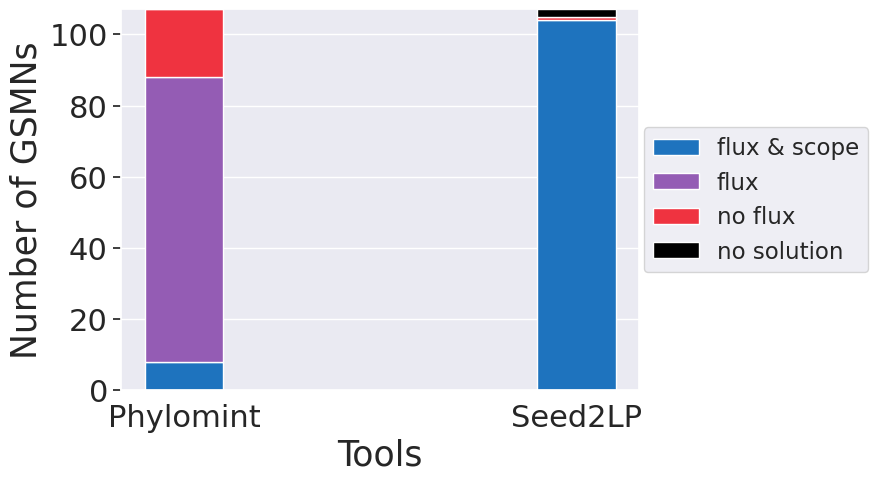

In [53]:
create_one_plot(s2lp_flux, phylomint_fluxes, ["Seed2LP", "Phylomint"], scope_s2lp, scope_phylomint)

### Scopes

Seed2LP  global mean:  89.35444227204987 	  PhyloMInt global mean:  85.60819403314743


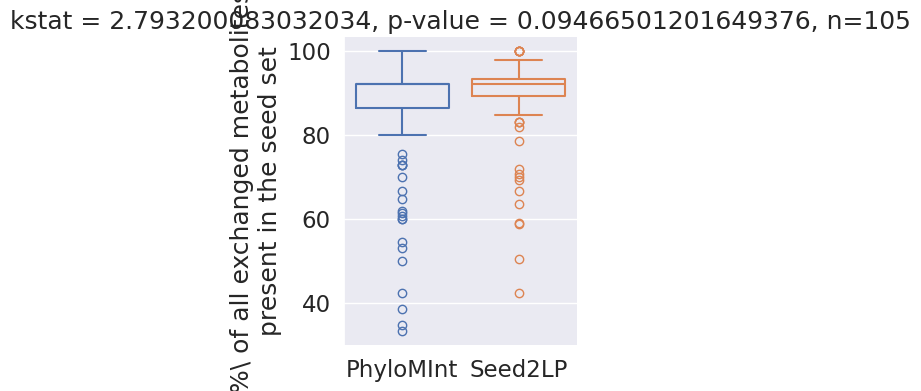

In [55]:
plot_compare(scope_s2lp, scope_phylomint, 'percentage_similar_exchange_into_seeds', ["Seed2LP","PhyloMInt"],
             y_label="%\ of all exchanged metabolites\npresent in the seed set")

Seed2LP  global mean:  28.184406328240268 	  PhyloMInt global mean:  20.711243782478686


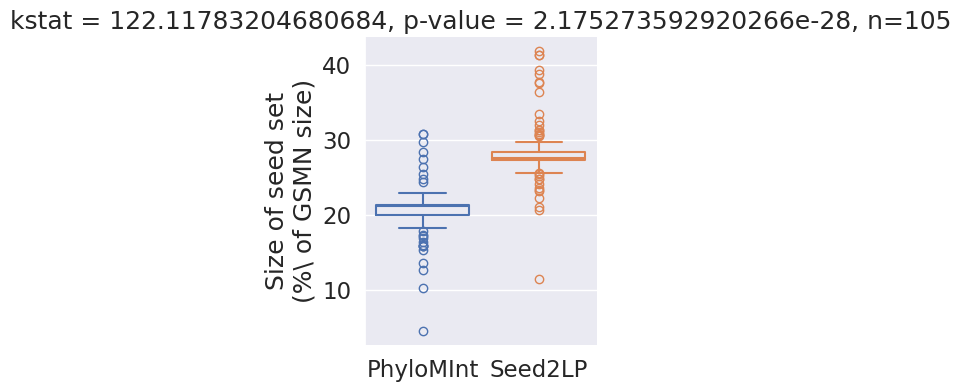

In [56]:
plot_compare(data_size_s2lp, data_size_phylomint, 'percent', ["Seed2LP","PhyloMInt"], 
             y_label="Size of seed set\n(%\ of GSMN size)")

Seed2LP  global mean:  100.0 	  PhyloMInt global mean:  81.84356555897303


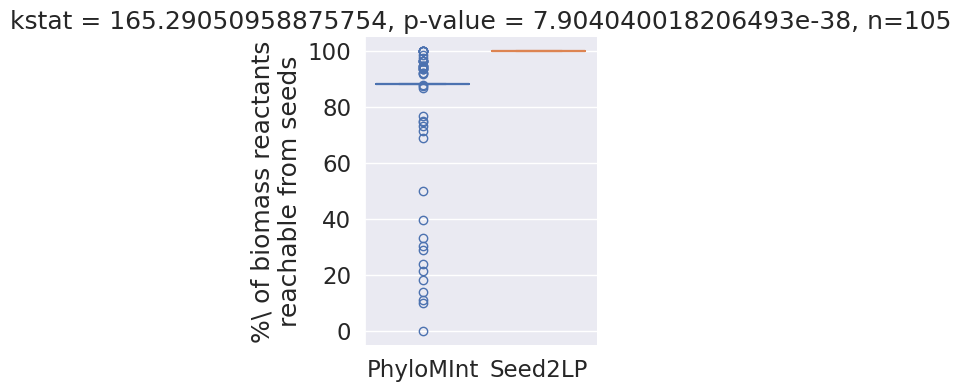

In [57]:
plot_compare(scope_s2lp, scope_phylomint, 'percentage_similar_biomass', ["Seed2LP","PhyloMInt"], 
             y_label="%\ of biomass reactants\nreachable from seeds")

Seed2LP  global mean:  100.0 	  PhyloMInt global mean:  85.66711668229544


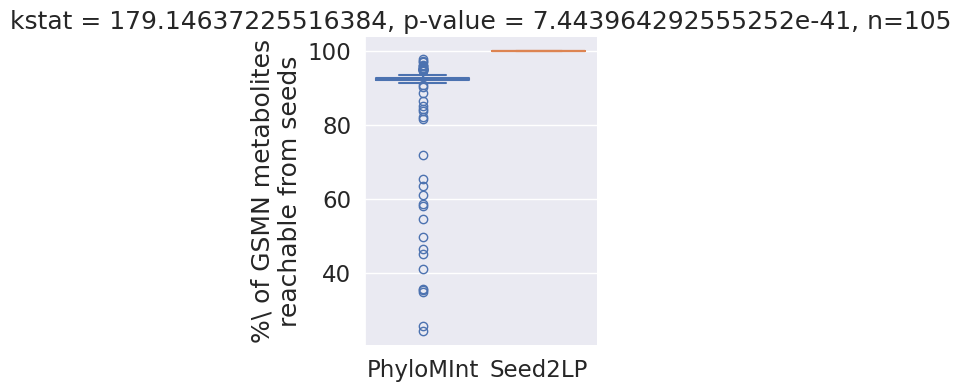

In [58]:
plot_compare(scope_s2lp, scope_phylomint, 'percentage_similar', ["Seed2LP","PhyloMInt"], 
             y_label="%\ of GSMN metabolites\nreachable from seeds")